In [88]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [89]:
data = pd.read_csv("Datasets\social_media_addiction_mental_wellbeing.csv")
data.head()

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,First_Check_Morning,Notifications_Per_Day,FOMO_Score,Social_Comparison_Score,Validation_Seeking_Score,Scroll_Without_Purpose,Tried_To_Cut_Back,Failed_To_Cut_Back,Anxiety_Score,Depression_Score,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,Male,Working Professional,In a Relationship,YouTube,2.9,4,3,No,Within 5 min,62,4.9,7.4,2.1,10.0,No,No,2.5,3.8,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,Low
1,USR00002,19,Male,Student,Married,Instagram,4.8,1,0,NaN,Within 5 min,111,4.2,5.4,7.2,9.0,Yes,Yes,4.0,3.2,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,Severe
2,USR00003,40,Male,Student,In a Relationship,YouTube,NaN,4,5,No,Within 5 min,122,2.7,NaN,5.9,6.1,No,Yes,7.6,0.0,5.6,5.3,6.3,NaN,5.8,2.8,0.0,1.5,5.6,High
3,USR00004,37,Female,Student,Married,Facebook,7.7,2,3,Yes,Within 5 min,48,3.9,8.3,4.9,4.1,NaN,No,3.3,3.5,5.6,1.4,3.9,6.1,5.5,3.6,1.0,3.9,4.3,Severe
4,USR00005,18,Non-binary,Student,In a Relationship,TikTok,4.6,3,0,No,5-30 min,58,6.0,8.6,2.8,7.3,Yes,NaN,6.5,0.0,4.0,NaN,5.7,5.0,3.8,3.2,0.6,1.0,6.6,Moderate


In [90]:
data.isnull().mean()*100

User_ID                         0.000000
Age                             0.000000
Gender                          3.533333
Occupation                      3.000000
Relationship_Status             3.400000
Primary_Platform                3.533333
Daily_Usage_Hours               3.733333
Platforms_Used_Count            0.000000
Posts_Per_Week                  0.000000
Late_Night_Usage                3.333333
First_Check_Morning             0.000000
Notifications_Per_Day           0.000000
FOMO_Score                      3.666667
Social_Comparison_Score         3.400000
Validation_Seeking_Score        3.866667
Scroll_Without_Purpose          0.000000
Tried_To_Cut_Back               2.733333
Failed_To_Cut_Back              2.866667
Anxiety_Score                   3.200000
Depression_Score                3.666667
Loneliness_Score                3.666667
Self_Esteem_Score               4.600000
Sleep_Quality_Score             4.533333
Sleep_Hours                     4.133333
Productivity_Los

In [91]:
newtoxicdata = data[['Gender','Occupation','Relationship_Status','Primary_Platform','Late_Night_Usage','Mental_Wellbeing_Score']]
newtoxicdata

,Gender,Occupation,Relationship_Status,Primary_Platform,Late_Night_Usage,Mental_Wellbeing_Score
0,Male,Working Professional,In a Relationship,YouTube,No,7.3
1,Male,Student,Married,Instagram,NaN,4.1
2,Male,Student,In a Relationship,YouTube,No,5.6
3,Female,Student,Married,Facebook,Yes,4.3
4,Non-binary,Student,In a Relationship,TikTok,No,6.6
...,...,...,...,...,...,...
1495,Male,Working Professional,In a Relationship,TikTok,No,6.5
1496,Non-binary,Student,Married,YouTube,Yes,6.4
1497,Female,Student,Single,Instagram,Yes,4.7
1498,Female,Freelancer,Single,Twitter/X,Yes,6.4


In [92]:
newtoxicdata.isnull().mean()*100

Gender                    3.533333
Occupation                3.000000
Relationship_Status       3.400000
Primary_Platform          3.533333
Late_Night_Usage          3.333333
Mental_Wellbeing_Score    0.000000
dtype: float64

In [93]:
x = newtoxicdata.iloc[:,0:5:]
y = newtoxicdata['Mental_Wellbeing_Score']

In [94]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [95]:
X_train

,Gender,Occupation,Relationship_Status,Primary_Platform,Late_Night_Usage
382,Non-binary,Working Professional,Single,YouTube,Yes
538,Male,Student,In a Relationship,TikTok,Yes
1493,Male,Student,Single,YouTube,Yes
1112,Male,Working Professional,Married,Facebook,No
324,Female,Unemployed,Single,Facebook,No
...,...,...,...,...,...
1130,Female,Student,Single,Instagram,No
1294,Male,Unemployed,In a Relationship,Instagram,No
860,Male,Working Professional,Married,YouTube,No
1459,Male,Student,Single,NaN,No


In [96]:
smi =SimpleImputer(strategy="most_frequent")

X_train = smi.fit_transform(X_train)
X_test = smi.transform(X_test)

In [97]:
X_test

array([['Male', 'Student', 'Single', 'TikTok', 'Yes'],
       ['Male', 'Working Professional', 'Married', 'Instagram', 'Yes'],
       ['Female', 'Student', 'In a Relationship', 'TikTok', 'Yes'],
       ...,
       ['Non-binary', 'Student', 'Single', 'Instagram', 'Yes'],
       ['Male', 'Student', 'Single', 'Instagram', 'Yes'],
       ['Non-binary', 'Student', 'In a Relationship', 'Instagram', 'No']],
      shape=(300, 5), dtype=object)

In [98]:
X_train

array([['Non-binary', 'Working Professional', 'Single', 'YouTube', 'Yes'],
       ['Male', 'Student', 'In a Relationship', 'TikTok', 'Yes'],
       ['Male', 'Student', 'Single', 'YouTube', 'Yes'],
       ...,
       ['Male', 'Working Professional', 'Married', 'YouTube', 'No'],
       ['Male', 'Student', 'Single', 'Instagram', 'No'],
       ['Male', 'Working Professional', 'Single', 'TikTok', 'No']],
      shape=(1200, 5), dtype=object)

In [103]:
newdata = pd.DataFrame(X_train)
newdata

,0,1,2,3,4
0,Non-binary,Working Professional,Single,YouTube,Yes
1,Male,Student,In a Relationship,TikTok,Yes
2,Male,Student,Single,YouTube,Yes
3,Male,Working Professional,Married,Facebook,No
4,Female,Unemployed,Single,Facebook,No
...,...,...,...,...,...
1195,Female,Student,Single,Instagram,No
1196,Male,Unemployed,In a Relationship,Instagram,No
1197,Male,Working Professional,Married,YouTube,No
1198,Male,Student,Single,Instagram,No


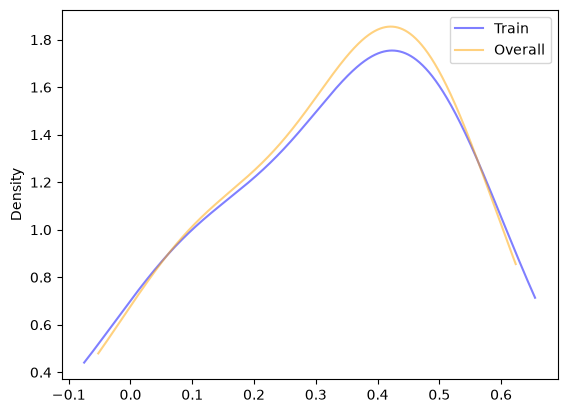

In [106]:
fig, ax = plt.subplots()
newdata[0].value_counts(normalize=True).plot(kind='kde', ax=ax, alpha=0.5, color='blue', label='Train')
data['Gender'].value_counts(normalize=True).plot(kind='kde', ax=ax, alpha=0.5, color='orange', label='Overall')
plt.legend()
plt.show()